# disease.sh — COVID-19 & Influenza Data

This notebook demonstrates the **disease.sh** accessor — a free, open-source API
providing global disease statistics with **no API key required**.

**Coverage:**
- Global & country-level COVID-19 statistics (cases, deaths, tests, vaccinations)
- Historical COVID-19 time series with configurable date ranges
- US state-level COVID-19 data
- US CDC influenza surveillance (ILINet, Public Health Lab, Clinical Lab)

**Docs:** https://disease.sh/docs/  |  **GitHub:** https://github.com/disease-sh/api

In [1]:
from epidatasets.sources.disease_sh import DiseaseShAccessor

ds = DiseaseShAccessor()
print(ds)

disease.sh — a free, open-source API providing global disease statistics including COVID-19 cases, deaths, testing, vaccinations, and US CDC influenza surveillance data. (https://disease.sh/)


## 1. Available diseases

In [2]:
ds.get_available_diseases()

,disease_key,disease_name,description,endpoints
0,covid19,COVID-19,"Global COVID-19 cases, deaths, testing, and va...","all, countries, historical, vaccine, states"
1,influenza,Influenza,"US CDC influenza surveillance (ILI, strain typ...","ilinet, public_health_lab, clinical_lab"


## 2. Global COVID-19 totals

Current worldwide aggregate figures.

In [3]:
totals = ds.get_global_totals()
totals[["cases", "deaths", "recovered", "active", "tests", "population"]]

INFO:epidatasets.sources.disease_sh:Loading cached data: /home/fccoelho/.cache/epi_data/disease_sh/v3_covid-19_all.json


,cases,deaths,recovered,active,tests,population
0,704753890,7010681,675619811,22123398,7026505313,7944935131


## 3. Countries covered

231 countries and territories, with ISO2/ISO3 codes and coordinates.

In [4]:
countries = ds.list_countries()
print(f"{len(countries)} countries")
countries.head()

INFO:epidatasets.sources.disease_sh:Loading cached data: /home/fccoelho/.cache/epi_data/disease_sh/v3_covid-19_countries_allowNull-false.json


231 countries


,country_code,country_name,iso3,lat,long
0,AF,Afghanistan,AFG,33.0,65.0
1,AL,Albania,ALB,41.0,20.0
2,DZ,Algeria,DZA,28.0,3.0
3,AD,Andorra,AND,42.5,1.6
4,AO,Angola,AGO,-12.5,18.5


## 4. Per-country current data

Latest COVID-19 statistics for a specific country (accepts name, ISO2 or ISO3).

In [5]:
brazil = ds.get_country_data(country="Brazil")
brazil[["country", "country_code", "cases", "deaths", "population", "casesPerOneMillion"]]

INFO:epidatasets.sources.disease_sh:Loading cached data: /home/fccoelho/.cache/epi_data/disease_sh/v3_covid-19_countries_Brazil.json


,country,country_code,cases,deaths,population,casesPerOneMillion
0,Brazil,BR,38743918,711380,215353593,179908


## 5. Historical time series

Daily cumulative series with optional date-range filtering.
Dates are parsed from the API's `M/D/YY` format into proper datetimes.

In [6]:
hist = ds.get_historical(
    country=["USA", "BRA", "IND"],
    lastdays=90,
    start_date="2023-01-01",
    end_date="2023-01-31",
)
hist.tail()

INFO:epidatasets.sources.disease_sh:Loading cached data: /home/fccoelho/.cache/epi_data/disease_sh/v3_covid-19_historical_USA,BRA,IND_lastdays-90.json


,country,province,date,cases,deaths,recovered
88,USA,mainland,2023-01-27,102270311,1107661,0
89,USA,mainland,2023-01-28,102274906,1107676,0
90,USA,mainland,2023-01-29,102278398,1107690,0
91,USA,mainland,2023-01-30,102307529,1107918,0
92,USA,mainland,2023-01-31,102362870,1108688,0


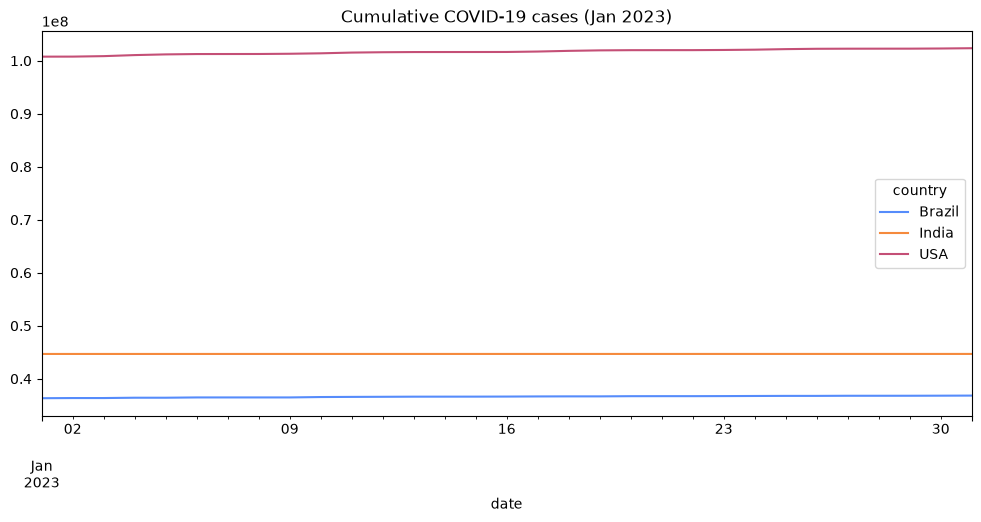

In [7]:
hist.pivot_table(index="date", columns="country", values="cases").plot(
    figsize=(12, 5), title="Cumulative COVID-19 cases (Jan 2023)"
);

## 6. Vaccine coverage

Global or per-country vaccination coverage time series.

In [8]:
vax = ds.get_vaccine_coverage(country="USA", lastdays=60)
vax[["country", "date", "total", "daily", "totalPerHundred"]].tail()

INFO:epidatasets.sources.disease_sh:Loading cached data: /home/fccoelho/.cache/epi_data/disease_sh/v3_covid-19_vaccine_coverage_countries_fullData-true_lastdays-60.json


,country,date,total,daily,totalPerHundred
55,USA,2025-07-17,676728782,0,0
56,USA,2025-07-18,676728782,0,0
57,USA,2025-07-19,676728782,0,0
58,USA,2025-07-20,676728782,0,0
59,USA,2025-07-21,676728782,0,0


## 7. US state-level data

In [9]:
states = ds.get_states()
states.nlargest(10, "cases")[["state", "cases", "deaths", "population"]]

INFO:epidatasets.sources.disease_sh:Loading cached data: /home/fccoelho/.cache/epi_data/disease_sh/v3_covid-19_states.json


,state,cases,deaths,population
0,California,12711918,112443,39512223
1,Texas,9190299,104793,28995881
2,Florida,8048191,95206,21477737
3,New York,7587861,83374,19453561
4,Illinois,4136659,42005,12671821
5,Ohio,3741277,43896,11689100
6,Pennsylvania,3565499,51480,12801989
7,North Carolina,3501404,29059,10488084
8,Michigan,3306221,44762,9986857
9,New Jersey,3295020,36873,8882190


## 8. US CDC Influenza surveillance

Weekly influenza data sourced from the US CDC, available via three endpoints.

In [10]:
ds.get_influenza_summary()

,endpoint_key,url,description,method
0,ilinet,https://disease.sh/v3/influenza/CDC/ILINet,US CDC ILINet ILI surveillance (by age group),get_influenza_ilinet
1,public_health_lab,https://disease.sh/v3/influenza/CDC/USPHL,US CDC Public Health Lab strain typing,get_influenza_public_health_lab
2,clinical_lab,https://disease.sh/v3/influenza/CDC/USCL,US CDC Clinical Lab totals and % positive,get_influenza_clinical_lab


### ILINet — Influenza-like illness by age group

The `week` field (`"YYYY - WW/52"`) is split into `year` and `week_num` columns.

In [11]:
ili = ds.get_influenza_ilinet()
ili[["year", "week_num", "totalILI", "totalPatients", "percentWeightedILI"]].tail()

INFO:epidatasets.sources.disease_sh:Loading cached data: /home/fccoelho/.cache/epi_data/disease_sh/v3_influenza_CDC_ILINet.json


,year,week_num,totalILI,totalPatients,percentWeightedILI
37,2022,25,36878,1926133,1.8
38,2022,26,33618,1873019,1.8
39,2022,27,33990,1900506,1.8
40,2022,28,31961,1915267,1.6
41,2022,29,30450,1894734,1.6


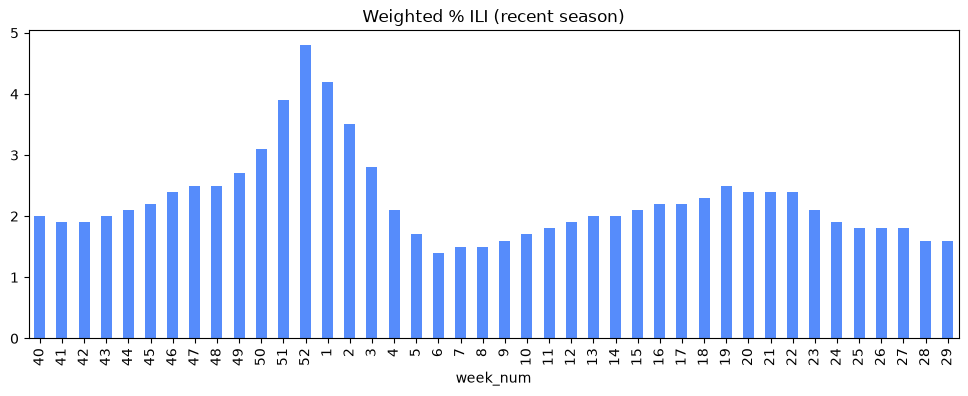

In [12]:
ili_recent = ili.dropna(subset=["year"]).tail(52)
ili_recent.plot(
    x="week_num",
    y="percentWeightedILI",
    kind="bar",
    figsize=(12, 4),
    title="Weighted % ILI (recent season)",
    legend=False,
);

### Clinical Lab — totals and percent positive

In [13]:
clin = ds.get_influenza_clinical_lab()
clin[["year", "week_num", "totalA", "totalB", "percentPositive", "totalTests"]].tail()

INFO:epidatasets.sources.disease_sh:Loading cached data: /home/fccoelho/.cache/epi_data/disease_sh/v3_influenza_CDC_USCL.json


,year,week_num,totalA,totalB,percentPositive,totalTests
37,2022,25,1084,40,1.69,66492
38,2022,26,777,37,1.27,64004
39,2022,27,578,29,0.97,62353
40,2022,28,409,44,0.87,51824
41,2022,29,299,23,0.72,44445


## 9. Using the registry

The accessor is also reachable through the plugin registry.

In [14]:
from epidatasets import get_source, list_sources

print("disease_sh" in list_sources())
ds2 = get_source("disease_sh")
ds2.get_global_totals()[["cases", "deaths"]]

INFO:epidatasets.sources.eurostat:eurostat library not installed. Using REST API fallback.
INFO:epidatasets.sources.disease_sh:Loading cached data: /home/fccoelho/.cache/epi_data/disease_sh/v3_covid-19_all.json


True


,cases,deaths
0,704753890,7010681


## 10. Error handling & caching

Invalid countries raise a clear `ValueError`, and request failures are wrapped in
`DiseaseShAPIError` carrying the `url`, HTTP `status_code` and number of `attempts`
for retry diagnostics. 4xx client errors fail fast without retrying.

Responses are cached on disk with a configurable time-to-live.

In [15]:
from epidatasets.sources.disease_sh import DiseaseShAPIError

# Invalid country -> ValueError with guidance
try:
    ds.get_country_data("Atlantis")
except ValueError as e:
    print(f"ValueError: {e}")

# API failures -> DiseaseShAPIError with retry info
try:
    ds._get("/v3/covid-19/nonexistent", use_cache=False)
except DiseaseShAPIError as e:
    print(f"DiseaseShAPIError: status={e.status_code}, attempts={e.attempts}")
    print(f"  url={e.url}")

INFO:epidatasets.sources.disease_sh:Fetching https://disease.sh/v3/covid-19/countries/Atlantis (attempt 1/3)
ERROR:epidatasets.sources.disease_sh:Failed to fetch https://disease.sh/v3/covid-19/countries/Atlantis after 1 attempt(s): 404 Client Error: Not Found for url: https://disease.sh/v3/covid-19/countries/Atlantis
INFO:epidatasets.sources.disease_sh:Fetching https://disease.sh/v3/covid-19/nonexistent (attempt 1/3)


ValueError: Unknown country: 'Atlantis'. Use a country name, ISO-2 or ISO-3 code (see list_countries()).


ERROR:epidatasets.sources.disease_sh:Failed to fetch https://disease.sh/v3/covid-19/nonexistent after 1 attempt(s): 404 Client Error: Not Found for url: https://disease.sh/v3/covid-19/nonexistent


DiseaseShAPIError: status=404, attempts=1
  url=https://disease.sh/v3/covid-19/nonexistent


In [16]:
# Cache TTL is configurable at construction time
ds_cached = DiseaseShAccessor(cache_ttl_hours=1)  # ~1h suits COVID; use ~24h for influenza

# use_cache=False bypasses the cache and forces a fresh request
fresh = ds_cached.get_global_totals(use_cache=False)
fresh[["cases", "deaths", "updated"]]

INFO:epidatasets.sources.disease_sh:Fetching https://disease.sh/v3/covid-19/all (attempt 1/3)


,cases,deaths,updated
0,704753890,7010681,2026-08-24 13:51:18.628
